# Mod3_Final Assessment - Statistical Analysis

In this phase, the cleaned dataset is examined through a statistical approach in order to better understand the main patterns in the data.

First, the numerical variables are analyzed by calculating descriptive statistics such as mean, median, mode, standard deviation, and range. Outliers are also identified using the IQR rule, and correlations between numerical variables are explored through a heatmap.

Next, the categorical variables are analyzed by examining their frequency distributions. This helps describe the composition of the customer base in terms of demographic characteristics and loyalty program features.

Throughout this phase, the numerical and categorical results are not only presented, but also briefly interpreted in clear business-oriented language.

In [1]:
# Import libraries
import pandas as pd
from pathlib import Path
import sys

# Add the /src folder to the Python path in order to import custom functions
sys.path.append(str(Path("../src").resolve()))

# Import support functions for numerical and categorical analysis
from support_stadistics import numerical_variables_analysis, categorical_variables_analysis

# Display all columns when printing DataFrames
pd.set_option("display.max_columns", None)


In [ ]:
# # Load the cleaned dataset generated in Phase 1

df = pd.read_csv("../files/processed/merged_dataset_v2.csv")

df.head() # Display the first rows to confirm the structure

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,100018,2017,1,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN
1,100102,2017,1,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,73479.0,Single,Nova,2887.74,Standard,2013,3,NaN,NaN
2,100140,2017,1,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,73479.0,Divorced,Nova,2838.07,Standard,2016,7,NaN,NaN
3,100214,2017,1,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,NaN,NaN
4,100272,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,NaN,NaN


Before starting the statistical analysis, the cleaned dataset is loaded. This version already includes the corrections made during the previous phase, such as missing value treatment and duplicate handling, and is therefore ready for analytical use.

In [ ]:
# Remove Loyalty Number from the statistical analysis dataset. It is an ID variable with no analytical meaning, and keeping it could distort statistical results.

df_analysis = df.drop(columns=["Loyalty Number"]).copy()

df_analysis.head()

,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,2017,1,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN
1,2017,1,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,73479.0,Single,Nova,2887.74,Standard,2013,3,NaN,NaN
2,2017,1,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,73479.0,Divorced,Nova,2838.07,Standard,2016,7,NaN,NaN
3,2017,1,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,NaN,NaN
4,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,NaN,NaN


## 1. Numerical Variables Analysis

NUMERICAL VARIABLES ANALYSIS

Column: Year
Count: 403760
Mean: 2017.5
Median: 2018.0
Mode: 2018
Standard deviation: 0.5
Minimum: 2017
Maximum: 2018
Outliers: 0
------------------------------
Column: Month
Count: 403760
Mean: 6.5
Median: 7.0
Mode: 11
Standard deviation: 3.45
Minimum: 1
Maximum: 12
Outliers: 0
------------------------------
Column: Flights Booked
Count: 403760
Mean: 4.13
Median: 1.0
Mode: 0
Standard deviation: 5.23
Minimum: 0
Maximum: 21
Outliers: 528
------------------------------
Column: Flights with Companions
Count: 403760
Mean: 1.04
Median: 0.0
Mode: 0
Standard deviation: 2.08
Minimum: 0
Maximum: 11
Outliers: 71560
------------------------------
Column: Total Flights
Count: 403760
Mean: 5.17
Median: 1.0
Mode: 0
Standard deviation: 6.53
Minimum: 0
Maximum: 32
Outliers: 1984
------------------------------
Column: Distance
Count: 403760
Mean: 1214.46
Median: 525.0
Mode: 0
Standard deviation: 1434.1
Minimum: 0
Maximum: 6293
Outliers: 125
------------------------------
C

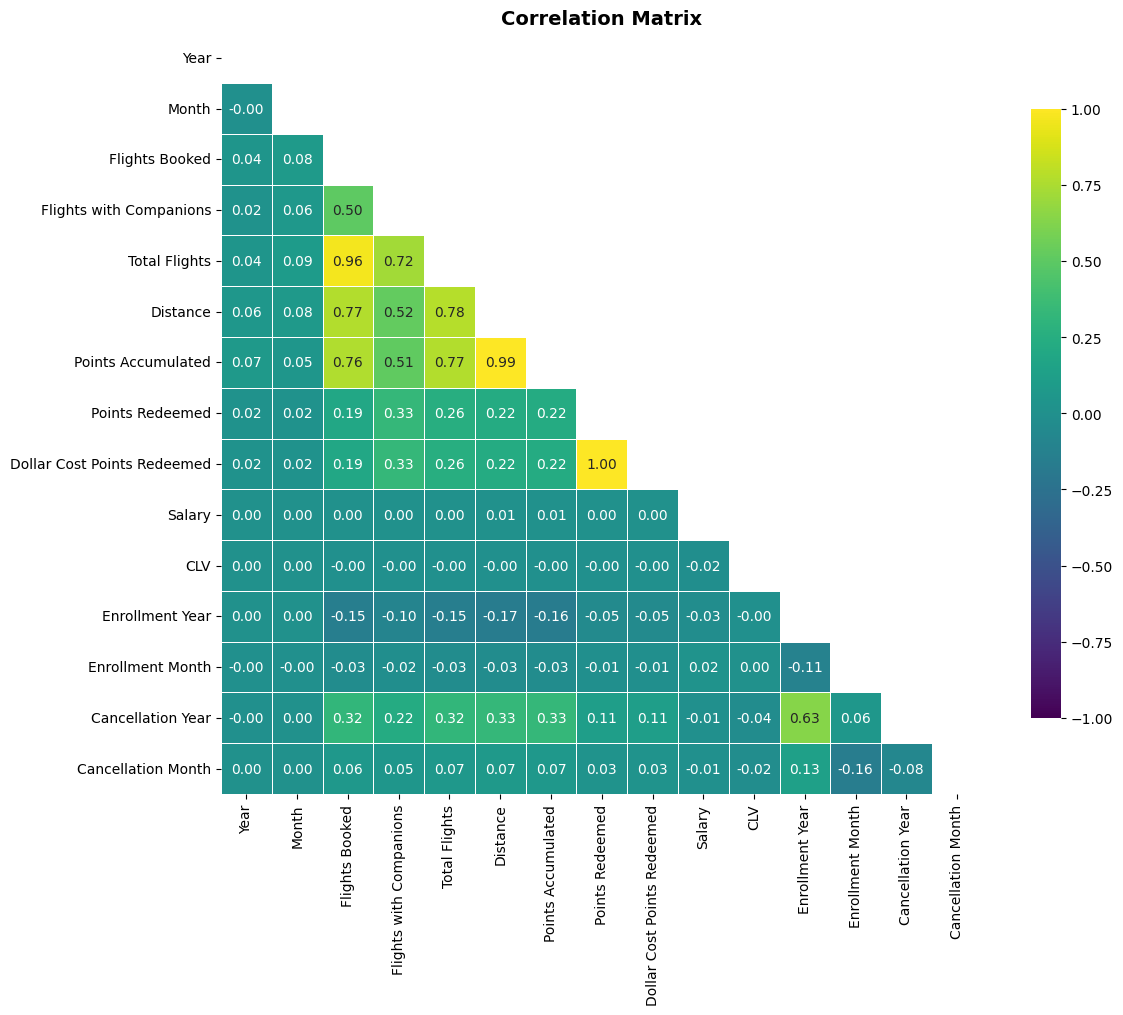

In [4]:
# Perform descriptive statistics, outlier detection, and correlation analysis for the numerical variables in the dataset

numerical_variables_analysis(df_analysis)

The numerical analysis shows clear differences in variability across the dataset.

Flight-related variables such as **Flights Booked**, **Total Flights**, **Distance**, and **Points Accumulated** are highly right-skewed: most customers show low activity, while a smaller group records much higher values. This pattern is consistent with a loyalty program in which most users are occasional travelers and a minority are highly active customers.

The outlier counts identified through the IQR rule are therefore expected and should not automatically be interpreted as data errors. In this context, they are more likely to reflect genuine behavioral differences between customers.

Regarding correlations, the strongest positive relationships appear between **Distance** and **Points Accumulated**, and between **Points Redeemed** and **Dollar Cost Points Redeemed**. This is coherent with the logic of the dataset, since accumulated points are closely linked to flight distance, and the dollar cost of redeemed points is directly associated with the number of redeemed points.

Strong positive correlations are also observed between **Flights Booked**, **Total Flights**, **Distance**, and **Points Accumulated**, suggesting that customers who fly more frequently also tend to travel longer distances and accumulate more points.

Overall, the numerical results describe a customer base with heterogeneous behavior, where flight activity and point generation are strongly connected.

## 2. Categorical Variables Analysis

In [5]:
# Perform frequency distribution analysis for categorical variables

categorical_variables_analysis(df)

CATEGORICAL VARIABLES ANALYSIS

Column: Country


,Count,Percentage (%)
Country,,
Canada,403760,100.0


----------------------------------------
Column: Province


,Count,Percentage (%)
Province,,
Ontario,130258,32.26
British Columbia,106442,26.36
Quebec,79573,19.71
Alberta,23360,5.79
Manitoba,15900,3.94
New Brunswick,15352,3.80
Nova Scotia,12507,3.10
Saskatchewan,9861,2.44
Newfoundland,6244,1.55


----------------------------------------
Column: City


...

----------------------------------------
Column: Loyalty Card


,Count,Percentage (%)
Loyalty Card,,
Star,183745,45.51
Nova,136883,33.90
Aurora,83132,20.59


----------------------------------------
Column: Enrollment Type


,Count,Percentage (%)
Enrollment Type,,
Standard,380419,94.22
2018 Promotion,23341,5.78


----------------------------------------


The categorical analysis reveals a fairly concentrated customer profile in several dimensions.

All customers belong to **Canada**, which is expected given the structure of the dataset. In geographical terms, **Ontario** is the most represented province, and **Toronto** is the most frequent city, indicating that customer activity is concentrated in specific regions.

In demographic terms, the distribution by **Gender** is relatively balanced, with a slight predominance of female customers. Most customers have a **Bachelor's degree**, followed by **College**, which suggests that the customer base is concentrated in intermediate-to-high education levels. The most common marital status is **Married**.

Regarding the loyalty program, the most common card type is **Star**, followed by **Nova**, while **Standard** is by far the most frequent enrollment type. This suggests that the majority of customers follow the standard access path to the program rather than entering through promotional campaigns.

Overall, the categorical variables point to a customer base with some diversity, but also with clear concentration in specific demographic, geographic, and loyalty-related categories.

## Conclusion

The statistical analysis provides a clearer view of the structure and behavior of the customer base.

From the numerical perspective, the dataset is characterized by strong asymmetry in several flight-related variables, with most customers showing low activity levels and a smaller segment displaying much higher engagement. Correlation analysis also shows that flight volume, distance, and loyalty point generation are closely connected.

From the categorical perspective, the data reveals concentration in specific provinces, cities, education levels, and loyalty card types, helping define the general customer profile of the program.

Overall, this phase confirms that the dataset contains meaningful patterns and is suitable for moving forward to the visualization phase, where these findings can be communicated more clearly through charts.